# P1 · 02 — Measure first, model later: baselines, metrics & backtesting

The most important habit in applied forecasting: **establish the yardstick before
building models.** This notebook sets up the three pieces every later notebook
reuses (all live in `src/`):

1. **Baselines** — naive, seasonal-naive, drift, mean. The bar to beat.
2. **Metrics** — MAE, RMSE, MAPE, sMAPE, and especially **MASE**.
3. **Rolling-origin backtesting** — the leak-free way to estimate accuracy.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import baselines as B, metrics as M, backtest as bt
q = data.load_quarterly()
y = q["gdp_nsa"]

### The baselines (and why they're not a joke)

| baseline | rule | beats it means |
|----------|------|----------------|
| `naive` | next = last value | you've captured *some* dynamics |
| `seasonal_naive(4)` | next = same quarter last year | you beat pure seasonality |
| `drift` | last value + average slope | you beat a straight-line trend |
| `mean` | the historical average | (only sane for stationary series) |

A "sophisticated" model that can't beat `seasonal_naive` is wasting everyone's
time. Let's first eyeball them on a simple **8-quarter holdout**.

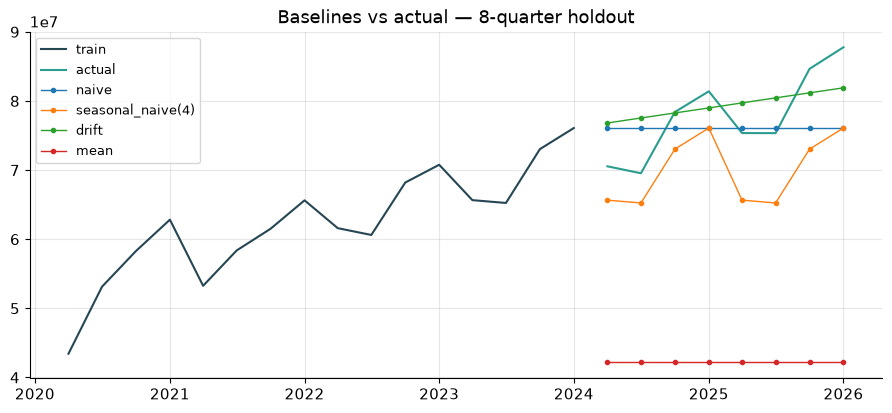

In [2]:
H = 8
train, test = y.iloc[:-H], y.iloc[-H:]
preds = {
    "naive":             B.naive(train, H),
    "seasonal_naive(4)": B.seasonal_naive(4)(train, H),
    "drift":             B.drift(train, H),
    "mean":              B.mean(train, H),
}
fig, ax = plt.subplots()
plots.plot_forecast(train.iloc[-16:], test=test,
                    title="Baselines vs actual — 8-quarter holdout", ax=ax)
xt = test.index.to_timestamp(how="start")
for name, p in preds.items():
    ax.plot(xt, p, marker="o", ms=3, lw=1, label=name)
ax.legend(loc="upper left", fontsize=9); plt.show()

### Metrics — and why MASE is the one to trust

* **MAE / RMSE** — error in original units; RMSE punishes big misses harder.
* **MAPE** — percent error; *popular but treacherous* (explodes near zero,
  asymmetric — penalises over-forecasts more than under-forecasts).
* **MASE** — MAE scaled by the in-sample seasonal-naive error.
  **MASE < 1 ⇒ better than naive; MASE > 1 ⇒ worse.** Scale-free and honest.

In [3]:
rows = {name: M.evaluate(test.values, p, y_train=train.values, season_length=4)
        for name, p in preds.items()}
pd.DataFrame(rows).T.sort_values("MASE").round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
drift,4.452693e+06,5.008395e+06,5.859,5.731,1.458
naive,5.179708e+06,6.306111e+06,6.517,6.645,1.696
seasonal_naive(4),7.873900e+06,8.421290e+06,9.978,10.568,2.578
mean,3.567862e+07,3.618732e+07,45.489,59.073,11.682


A single holdout is one sample of "how good is this model?" — and the tail you
happened to pick could be unusually easy or hard. **Rolling-origin backtesting**
fixes that: slide the train/test cutoff across the series, refit at each step, and
average the out-of-sample errors. Our `src/backtest.py` does this for *any*
forecaster with the same `f(train, h)` signature.

In [4]:
fcs = {"naive": B.naive, "seasonal_naive(4)": B.seasonal_naive(4),
       "drift": B.drift, "mean": B.mean}
table = bt.compare(y, fcs, initial=40, h=4, step=1, season_length=4)
table.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
drift,3.322822e+06,4.827551e+06,5.627,5.591,1.014
naive,4.051327e+06,5.259799e+06,6.846,6.969,1.236
seasonal_naive(4),4.138716e+06,4.655609e+06,7.221,7.392,1.263
mean,2.235950e+07,2.351980e+07,37.226,46.036,6.824


This table — averaged over *many* cutoffs — is far more trustworthy than the
single holdout above. Note `mean` is hopeless (GDP trends hard), while `drift`
and `seasonal_naive` are competitive. All baselines sit near **MASE ≈ 1** by
construction; that's the line our ETS and ARIMA models must get **below**.

Finally, error almost always **grows with the forecast horizon** — predicting 4
quarters out is harder than 1. Let's quantify it for `drift`:

In [5]:
res = bt.rolling_origin(y, B.drift, initial=40, h=4, step=1)
bt.summarize_by_horizon(res).round(0)

,MAE,RMSE
step_ahead,,
1,3255351.0,4707925.0
2,4421442.0,5771564.0
3,3416206.0,5104485.0
4,2198291.0,3419025.0


MAE/RMSE rise monotonically with `step_ahead` — exactly as expected. Always
report accuracy **per horizon**, because "the model is accurate" is meaningless
without saying *how far ahead*.

---
**You now have the yardstick.** Everything from here (ETS in 03, ARIMA/SARIMA in
04) must beat these baselines on this backtest. That is the whole game.